Unshuffled Mean: 33.0833
Shuffled Mean:   8.1667

T-statistic: 5.5602
P-value:      2.0167e-07


/var/folders/zk/lv_zrs9910s49_109vbgf6c40000gn/T/ipykernel_39260/1510596587.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([unshuffled_rates, shuffled_rates], labels=['Unshuffled', 'Shuffled'])


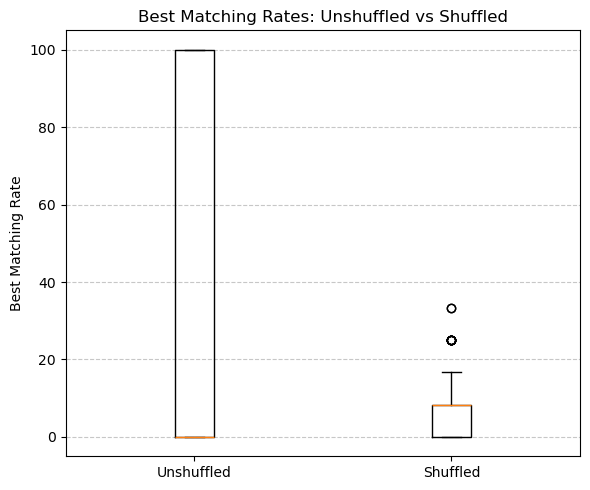

In [7]:
import os
import pickle
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
import numpy as np

def load_matching_rates(folder):
    rates = []
    for fname in sorted(os.listdir(folder)):
        if fname.startswith("iteration_") and fname.endswith(".pkl"):
            with open(os.path.join(folder, fname), "rb") as f:
                data = pickle.load(f)
                if "best_matching_rate" in data:
                    rates.append(data["best_matching_rate"])
    return rates

# Load both groups
unshuffled_folder = "gwot_results_similarity_distance_averaged"
shuffled_folder ="gwot_results_similarity_distance_averaged_shuffled"

unshuffled_rates = load_matching_rates(unshuffled_folder)
shuffled_rates = load_matching_rates(shuffled_folder)

# T-test
t_stat, p_val = ttest_ind(unshuffled_rates, shuffled_rates, equal_var=False)

# Print results
print(f"Unshuffled Mean: {sum(unshuffled_rates)/len(unshuffled_rates):.4f}")
print(f"Shuffled Mean:   {sum(shuffled_rates)/len(shuffled_rates):.4f}")
print(f"\nT-statistic: {t_stat:.4f}")
print(f"P-value:      {p_val:.4e}")

# Optional: Boxplot to visualize distributions
plt.figure(figsize=(6, 5))
plt.boxplot([unshuffled_rates, shuffled_rates], labels=['Unshuffled', 'Shuffled'])
plt.title("Best Matching Rates: Unshuffled vs Shuffled")
plt.ylabel("Best Matching Rate")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


Unshuffled Mean:  33.0833
Unshuffled Median:0.0000
Shuffled Mean:    8.1667
Shuffled Median:  8.3333

Mann–Whitney U statistic: 5489.5000
P-value:                  8.9709e-01

❌ The result is NOT statistically significant (p ≥ 0.05).


/var/folders/zk/lv_zrs9910s49_109vbgf6c40000gn/T/ipykernel_39260/1239796763.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([unshuffled_rates, shuffled_rates], labels=['Unshuffled', 'Shuffled'])


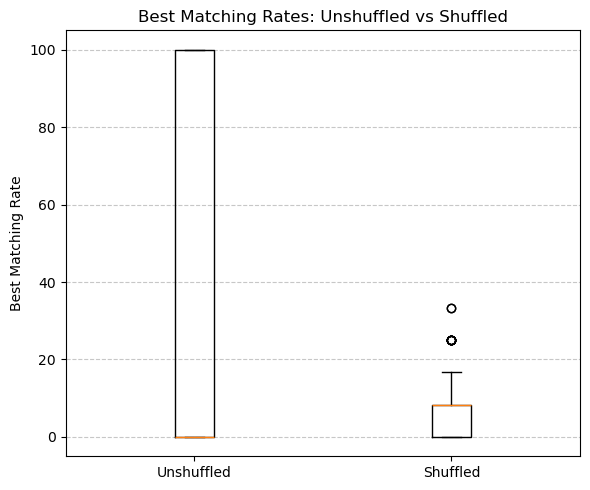

In [15]:

unshuffled_rates = load_matching_rates(unshuffled_folder)
shuffled_rates = load_matching_rates(shuffled_folder)

# Mann–Whitney U test
stat, p_val = mannwhitneyu(unshuffled_rates, shuffled_rates, alternative='less', method='auto')

# Compute statistics
mean_unshuffled = np.mean(unshuffled_rates)
median_unshuffled = np.median(unshuffled_rates)
mean_shuffled = np.mean(shuffled_rates)
median_shuffled = np.median(shuffled_rates)

# Print summary
print(f"Unshuffled Mean:  {mean_unshuffled:.4f}")
print(f"Unshuffled Median:{median_unshuffled:.4f}")
print(f"Shuffled Mean:    {mean_shuffled:.4f}")
print(f"Shuffled Median:  {median_shuffled:.4f}")
print(f"\nMann–Whitney U statistic: {stat:.4f}")
print(f"P-value:                  {p_val:.4e}")

# Significance interpretation
alpha = 0.05
if p_val < alpha:
    print("\n✅ The result is statistically significant (p < 0.05).")
else:
    print("\n❌ The result is NOT statistically significant (p ≥ 0.05).")

# Optional: Boxplot
plt.figure(figsize=(6, 5))
plt.boxplot([unshuffled_rates, shuffled_rates], labels=['Unshuffled', 'Shuffled'])
plt.title("Best Matching Rates: Unshuffled vs Shuffled")
plt.ylabel("Best Matching Rate")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


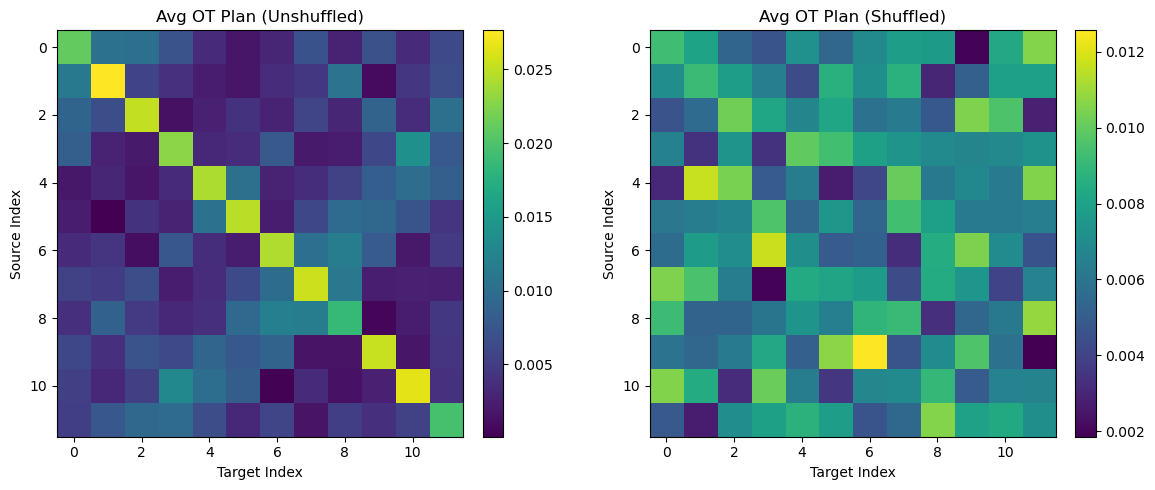

In [16]:
def load_ot_plans(folder):
    ot_plans = []
    for fname in sorted(os.listdir(folder)):
        if fname.startswith("iteration_") and fname.endswith(".pkl"):
            with open(os.path.join(folder, fname), "rb") as f:
                data = pickle.load(f)
                if "OT_plan" in data:
                    ot_plans.append(data["OT_plan"])
    return np.array(ot_plans)

unshuffled_ot = load_ot_plans(unshuffled_folder)
shuffled_ot = load_ot_plans(shuffled_folder)

# --- Compute average transport plan ---
avg_ot_unshuffled = np.mean(unshuffled_ot, axis=0)
avg_ot_shuffled = np.mean(shuffled_ot, axis=0)

# --- Plot heatmaps ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im0 = axes[0].imshow(avg_ot_unshuffled, cmap='viridis')
axes[0].set_title("Avg OT Plan (Unshuffled)")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(avg_ot_shuffled, cmap='viridis')
axes[1].set_title("Avg OT Plan (Shuffled)")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

for ax in axes:
    ax.set_xlabel("Target Index")
    ax.set_ylabel("Source Index")

plt.tight_layout()
plt.show()
